



### Problems: API's and Webscraping

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

#### Question 1

Using the LastFM API, look up your five favorite artists (using [here](https://www.last.fm/api/show/artist.getTopAlbums)) top albums and create a DataFrame of your results formatted as shown below:

| Artist | Album | Album Art Link |
| ------ | ------ | ------------  |
| Riff Raff | Pink Panther | www.lastfm.com/panther |
| Slayer | South of Heaven | www.lastfm.com/slay |

In [176]:
api_key = 'ef9ef5e7a2d57a6a2c57a88196e3d8ec'
fav_artists = ['陶喆', '方大同', '李健', '梁博', '孙燕姿']

In [175]:
"""
# check the structure of json output
url = "https://ws.audioscrobbler.com/2.0/"
params = {
        "method": "artist.getTopAlbums",
        "artist": artist,
        "api_key": api_key,
        "format": "json",
    }
r = requests.get(url, params=params)
data = r.json()
data
"""

{'topalbums': {'album': [{'name': '逆光',
    'playcount': 202716,
    'mbid': '9ef581ee-ae63-3ddc-839a-1ebf105dadcb',
    'url': 'https://www.last.fm/music/%E5%AD%AB%E7%87%95%E5%A7%BF/%E9%80%86%E5%85%89',
    'artist': {'name': '孫燕姿',
     'url': 'https://www.last.fm/music/%E5%AD%AB%E7%87%95%E5%A7%BF'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/691a081afad5cdaf20a958a52b5ace79.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/691a081afad5cdaf20a958a52b5ace79.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/691a081afad5cdaf20a958a52b5ace79.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/691a081afad5cdaf20a958a52b5ace79.png',
      'size': 'extralarge'}],
    '@attr': {'rank': '1'}},
   {'name': 'The moment',
    'playcount': 104618,
    'mbid': 'b6cce093-53b8-378d-b7fc-e7f60314a674',
    'url': 'https://www.last.fm/music/%E5%AD%AB%E7%87%95%E5

In [180]:
def get_top_albums(artist, limit=1):
    url = "https://ws.audioscrobbler.com/2.0/"
    params = {
        "method": "artist.getTopAlbums",
        "artist": artist,
        "api_key": api_key,
        "format": "json",
        "limit": limit
    }

    r = requests.get(url, params=params)
    data = r.json()

    # print(data) # debug line: uncomment to inspect the structure of JSON output
    albums = data["topalbums"]["album"]

    # return a big list of dictionaries for each artist's top album
    return [
        {
            "Artist": artist,
            "Album": a["name"],
            "Album Art Link": a["url"]
        }
        for a in albums
    ]

In [179]:
# create DataFrame
rows = []
for artist in fav_artists:
    rows.extend(get_top_albums(artist, limit=1))

df = pd.DataFrame(rows)

# hide index
df.style.hide(axis="index")

Artist,Album,Album Art Link
陶喆,Beautiful,https://www.last.fm/music/%E9%99%B6%E5%96%86/Beautiful
方大同,橙月,https://www.last.fm/music/%E6%96%B9%E5%A4%A7%E5%90%8C/%E6%A9%99%E6%9C%88
李健,依然,https://www.last.fm/music/%E6%9D%8E%E5%81%A5/%E4%BE%9D%E7%84%B6
梁博,尖叫之夜,https://www.last.fm/music/%E6%A2%81%E5%8D%9A/%E5%B0%96%E5%8F%AB%E4%B9%8B%E5%A4%9C
孙燕姿,逆光,https://www.last.fm/music/%E5%AD%AB%E7%87%95%E5%A7%BF/%E9%80%86%E5%85%89


#### Question 2

Using the LastFM API, look up tracks similar (using [this](https://www.last.fm/api/show/track.getSimilar)) to Quicksand's song Fazer.  Assemble the results in a DataFrame with the format given below:

| Artist | Song | Playcount | Match % | Duration |
| ------ | ------- | ------ | ------ | ---------- |
| quicksand | can opener | 98218 | 1.0 | 219 |

In [186]:
api_key = "ef9ef5e7a2d57a6a2c57a88196e3d8ec"

def get_similar(artist, track):
    url = "https://ws.audioscrobbler.com/2.0/"
    params = {
        "method": "track.getSimilar",
        "artist": artist,
        "track": track,
        "api_key": api_key,
        "format": "json"
    }

    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()

    tracks = data["similartracks"]["track"]

    out = []
    for t in tracks:
        out.append({
            # Use the artist of the returned similar track (NOT the input artist)
            "Artist": t["artist"]["name"],
            "Song": t["name"],
            "Playcount": int(t["playcount"]) if str(t.get("playcount", "")).isdigit() else None,
            "Match %": float(t["match"]) if t.get("match") is not None else None,
            "Duration": int(t["duration"]) if str(t.get("duration", "")).isdigit() else None
        })
    return out

In [187]:
# create DataFrame
df = pd.DataFrame(get_similar("Quicksand","Fazer"))

# hide index
df.style.hide(axis="index")

Artist,Song,Playcount,Match %,Duration
Quicksand,Head To Wall,222166,1.000000,187
Quicksand,Dine Alone,272134,0.940244,208
Helmet,In the Meantime,687210,0.172101,186
At the Drive-In,One Armed Scissor,3570218,0.171240,238
At the Drive-In,Arcarsenal,2089511,0.160933,175
Drive Like Jehu,Here Come The Rome Plows,532588,0.158353,343
Thursday,Standing On The Edge Of Summer,1161931,0.158074,222
Glassjaw,Mu Empire,785919,0.156672,224
Unwound,Corpse Pose,1457055,0.152392,187
Fugazi,Bed for the Scraping,720331,0.150917,165


#### Question 3

The world bank has a Python wrapper for its api called `wbgapi`.  Examine the documentation [here](https://pypi.org/project/wbgapi/) and chose an endpoint(s) to query.  Find at least two endpoints of interest and create visualizations of this data.  Write a sentence or two about what you've found.

In [36]:
# !pip install wbgapi

In [188]:
# Choose two endpoints
IND_GDP_PC = "NY.GDP.PCAP.CD"   # GDP per capita (current US$)
IND_POP    = "SP.POP.TOTL"      # Population, total

countries = ["CHN", "USA", "CAN"]         # China, US, Canada
years = range(2000, 2016)                 # 2000–2015 inclusive

In [190]:
# helper function: fetch_indicator
def fetch_indicator(indicator: str, label: str) -> pd.DataFrame:
    rows = []
    for r in wb.data.fetch(indicator, economy=countries, time=years):
        rows.append({
            "country": r["economy"],
            "year": int(r["time"].replace("YR","")),
            label: r["value"]
        })

    df = pd.DataFrame(rows)
    out = df.pivot(index="year", columns="country", values=label).sort_index()
    out.index.name = "Year"
    return out

In [191]:
# Fetch data
gdp_pc = fetch_indicator(IND_GDP_PC, "gdp_pc_usd")
pop    = fetch_indicator(IND_POP, "population")

# map codes to nicer labels for plots
country_names = {"CHN": "China", "BRA": "Brazil", "CAN": "Canada"}

gdp_pc = gdp_pc.rename(columns=country_names)
pop    = pop.rename(columns=country_names)

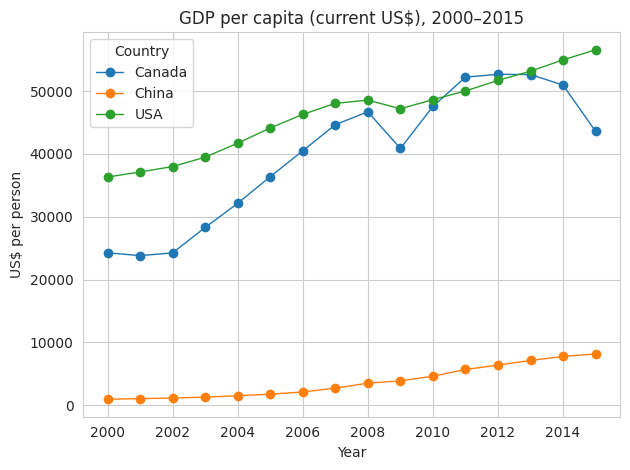

In [192]:
# Visualization
# ---- Plot 1: GDP per capita ----
plt.figure()
for c in gdp_pc.columns:
    plt.plot(gdp_pc.index, gdp_pc[c], marker="o", linewidth=1, label=c)
plt.title("GDP per capita (current US$), 2000–2015")
plt.xlabel("Year")
plt.ylabel("US$ per person")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

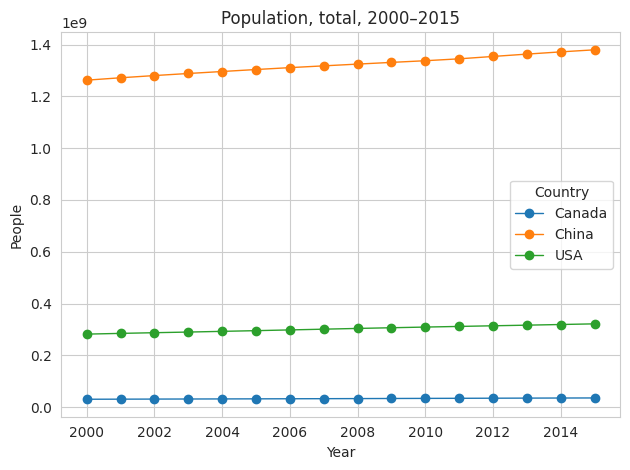

In [193]:
# ---- Plot 2: Population ----
plt.figure()
for c in pop.columns:
    plt.plot(pop.index, pop[c], marker="o", linewidth=1, label=c)
plt.title("Population, total, 2000–2015")
plt.xlabel("Year")
plt.ylabel("People")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

In [197]:
# ---- Numeric summary ----
summary = pd.DataFrame({
    "GDPpc_2000": gdp_pc.loc[2000],
    "GDPpc_2015": gdp_pc.loc[2015],

    # Percentage change in GDP per capita from 2000 → 2015
    # Formula: (final / initial − 1) × 100
    "GDPpc_%chg": (gdp_pc.loc[2015] / gdp_pc.loc[2000] - 1) * 100,

    "Pop_2000": pop.loc[2000],
    "Pop_2015": pop.loc[2015],

    # Percentage change in population from 2000 → 2015
    "Pop_%chg": (pop.loc[2015] / pop.loc[2000] - 1) * 100,
}).round(2)

print(summary)

         GDPpc_2000  GDPpc_2015  GDPpc_%chg    Pop_2000    Pop_2015  Pop_%chg
country                                                                      
Canada     24271.00    43594.19       79.61    30685730    35704498     16.36
China        969.20     8175.33      743.51  1262645000  1379860000      9.28
USA        36329.96    56572.92       55.72   282162411   321815121     14.05


Result:

China shows the most dramatic growth, with GDP per capita increasing over 7× from 2000 to 2015 while population rose only modestly, indicating rapid productivity and development gains. The U.S. and Canada started from much higher income levels and grew more steadily, reflecting mature economies with slower but stable population expansion.

#### Question 4


Find an api of interest to you -- here is a list of some but feel free to google around [api list](https://github.com/public-apis/public-apis).  Ask a specific question that you want to use the data from the api to answer, make an appropriate request of the endpoints and do your best to provide an answer to your question asked.

-------
For example, maybe I'm interested in finding out recent artists similar to Rod Stewart.  I could use the LastFM api for this.  Perhaps you're interested in a lyrical analysis of Drake vs. Kendrick Lamar -- and want to compare the lexical diversity of different tracks; you can use the genius api for this.  Maybe I want to build an app to show a random cat picture with a dad joke.  The cat api and jokes api might work here.

**API used:** aviationstack

**Question:** Which airline is currently performing best on flights from Tokyo (HND/NRT/KIX) to Shanghai (PVG/SHA) based on real-time delay performance?

**Answer:** Based on the current real-time snapshot, Spring Airlines Japan is performing best, with a 100% on-time rate and a low average delay of 9 minutes (though based on a small sample size).

In [198]:
# ---- SET UP ----
BASE_URL = "https://api.aviationstack.com/v1/flights"
ACCESS_KEY = "592f0b0648aea71103483b7c73465072"

# Input departure and arrival airports:
DEP_IATA_LIST = ["HND", "NRT", "KIX"]   # Japan major airports
ARR_IATA_LIST = ["PVG", "SHA"]         # Shanghai airports

# The flight is considered on-time if the delay time < 15
ON_TIME_THRESHOLD_MIN = 15

# Aviationstack free plan allows only 100 API requests per month.
LIMIT = 100

In [199]:
# helper function: fetch_realtime
def fetch_realtime(dep_iata: str, arr_iata: str) -> list[dict]:
    params = {
        "access_key": ACCESS_KEY,
        "dep_iata": dep_iata,
        "arr_iata": arr_iata,
        "limit": LIMIT,
    }

    r = requests.get(BASE_URL, params=params, timeout=30)
    payload = r.json()

    if r.status_code >= 400 or "error" in payload:
        raise RuntimeError(f"HTTP {r.status_code}: {payload}")

    return payload.get("data", []) or []

In [200]:
# helper function: to_df turns into DataFrame
def to_df(rows: list[dict]) -> pd.DataFrame:
    out = []
    for x in rows:
        # Extract airline name
        airline = (x.get("airline") or {}).get("name") or (x.get("airline") or {}).get("iata") or "UNKNOWN"

        # Extract flight status (e.g., active, landed, cancelled)
        status = x.get("flight_status") or "unknown"

        # Extract departure and arrival delay in minutes
        dep_delay = (x.get("departure") or {}).get("delay")
        arr_delay = (x.get("arrival") or {}).get("delay")

        # Extract flight and airport IATA codes
        flight_iata = (x.get("flight") or {}).get("iata")
        dep_iata = (x.get("departure") or {}).get("iata")
        arr_iata = (x.get("arrival") or {}).get("iata")

        out.append({
            "airline": airline,
            "status": status,
            "dep_delay_min": dep_delay,
            "arr_delay_min": arr_delay,
            "flight_iata": flight_iata,
            "dep_iata": dep_iata,
            "arr_iata": arr_iata,
        })

    df = pd.DataFrame(out)
    if df.empty:
        return df

    # Data cleaning
    # Convert delay columns to numeric (coerce invalid values to NaN)
    df["dep_delay_min"] = pd.to_numeric(df["dep_delay_min"], errors="coerce")
    df["arr_delay_min"] = pd.to_numeric(df["arr_delay_min"], errors="coerce")

    # Replace missing flight IATA codes with empty string
    df["flight_iata"] = df["flight_iata"].fillna("")
    return df

In [201]:
# helper function: reliability_snapshot
def reliability_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute a real-time reliability summary by airline.
    Metrics include number of flights, delay stats, and on-time percentage.
    """
    # Filter to only flights currently relevant for real-time monitoring
    # (exclude landed/cancelled/etc.)
    running = df[df["status"].isin(["active", "scheduled"])].copy()
    if running.empty:
        return running

    # Create a unified delay column:
    # use departure delay if available, otherwise arrival delay
    running["delay_used_min"] = running["dep_delay_min"].where(
        running["dep_delay_min"].notna(), running["arr_delay_min"]
    )

    # Optional cargo airline filter:
    # remove airlines whose names suggest freight-only operations
    cargo_keywords = ["cargo", "logistics", "freight", "express", "postal"]
    running = running[~running["airline"].str.lower().str.contains("|".join(cargo_keywords), na=False)]

    # Nested Aggregation function applied per airline group
    def agg(g):
        # Compute summary statistics for one airline.
        delays = g["delay_used_min"].dropna()
        n_total = len(g)
        n_known = len(delays)

        # If no delay data available, return NaN stats
        if n_known == 0:
            return pd.Series({
                "n_flights": n_total,
                "n_delay_known": 0,
                "avg_delay_min": float("nan"),
                "max_delay_min": float("nan"),
                "on_time_%": float("nan"),
            })

        # Otherwise compute metrics
        return pd.Series({
            "n_flights": n_total,
            "n_delay_known": n_known,
            "avg_delay_min": delays.mean(),
            "max_delay_min": delays.max(),
            "on_time_%": (delays <= ON_TIME_THRESHOLD_MIN).mean() * 100,
        })

    # Group flights by airline and compute reliability metrics
    summary = (
        running.groupby("airline")
        .apply(agg, include_groups=False)
        .reset_index()
    )

    # Round numeric metrics for cleaner display
    summary["avg_delay_min"] = summary["avg_delay_min"].round(1)
    summary["max_delay_min"] = summary["max_delay_min"].round(1)
    summary["on_time_%"] = summary["on_time_%"].round(1)

    """
    Sort airlines from best to worst:
    1. Higher on-time % is better
    2. Lower average delay is better
    3. Lower max delay is better
    4. More flights is better (larger sample reliability)
    """

    return summary.sort_values(
        by=["on_time_%", "avg_delay_min", "max_delay_min", "n_flights"],
        ascending=[False, True, True, False],
        na_position="last",
    )

In [87]:
from datetime import datetime, UTC
# NOTE Aviationstack free plan allows only 100 API requests per month.
# ---- RUN ----
# Record snapshot generation time
snapshot_time = datetime.now(UTC).strftime("%Y-%m-%d %H:%M:%S UTC")

all_rows = []
for dep in DEP_IATA_LIST:
    for arr in ARR_IATA_LIST:
        all_rows.extend(fetch_realtime(dep, arr))

df = to_df(all_rows)

# Best-effort de-duplication:
# The same flight may appear multiple times across route queries (or repeated API returns),
# so remove duplicates based on key identifiers + delay fields.
if not df.empty:
    df = df.drop_duplicates(subset=["flight_iata", "dep_iata", "arr_iata", "status", "dep_delay_min", "arr_delay_min"])

# Generate airline-level reliability metrics (on-time %, avg delay, max delay, etc.)
snap = reliability_snapshot(df)

print("Japan -> Shanghai (real-time) reliability snapshot")
print(f"Generated at: {snapshot_time}")  # timestamp label
print(f"Departure airports: {DEP_IATA_LIST} | Arrival airports: {ARR_IATA_LIST}")
print(f"On-time threshold: delay <= {ON_TIME_THRESHOLD_MIN} min\n")

if snap.empty:
    print("No active/scheduled flights returned at this moment. Try again at a different time.")
else:
    print(snap.to_string(index=False))

Japan -> Shanghai (real-time) reliability snapshot
Generated at: 2026-03-01 05:20:06 UTC
Departure airports: ['HND', 'NRT', 'KIX'] | Arrival airports: ['PVG', 'SHA']
On-time threshold: delay <= 15 min

                airline  n_flights  n_delay_known  avg_delay_min  max_delay_min  on_time_%
  Spring Airlines Japan        2.0            1.0            9.0            9.0      100.0
China Southern Airlines        1.0            1.0           13.0           13.0      100.0
        Spring Airlines        5.0            2.0           34.5           65.0       50.0
          Air China LTD        8.0            5.0           20.2           39.0       40.0
                    ANA        9.0            6.0           22.5           39.0       16.7
       Juneyao Airlines        7.0            7.0           18.7           30.0       14.3
         Japan Airlines       23.0           10.0           21.9           37.0       10.0
 China Eastern Airlines       16.0           11.0           21.5      

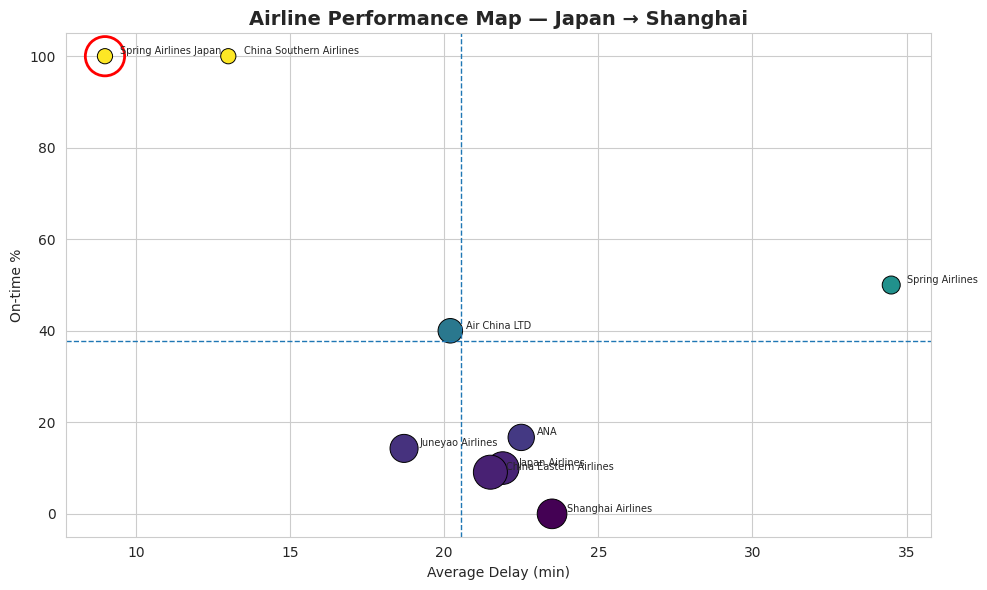

In [206]:
plot_df = snap.dropna(subset=["avg_delay_min","on_time_%"]).copy()
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# scatter
ax = sns.scatterplot(
    data=plot_df,
    x="avg_delay_min",
    y="on_time_%",
    size="n_delay_known",
    sizes=(120,600),
    hue="on_time_%",
    palette="viridis",
    edgecolor="black",
    linewidth=0.7,
    legend=False
)

# quadrant reference lines
plt.axhline(plot_df["on_time_%"].mean(), linestyle="--", linewidth=1)
plt.axvline(plot_df["avg_delay_min"].mean(), linestyle="--", linewidth=1)

# highlight best airline
best = plot_df.sort_values(
    ["on_time_%","avg_delay_min"],
    ascending=[False,True]
).iloc[0]

plt.scatter(
    best["avg_delay_min"],
    best["on_time_%"],
    s=800,
    facecolors="none",
    edgecolors="red",
    linewidth=2
)

# labels next to points
for _, r in plot_df.iterrows():
    plt.text(
        r["avg_delay_min"] + 0.5,
        r["on_time_%"] + 0.5,
        r["airline"],
        fontsize=7
    )

plt.title("Airline Performance Map — Japan → Shanghai", fontsize=14, weight="bold")
plt.xlabel("Average Delay (min)")
plt.ylabel("On-time %")

plt.tight_layout()
plt.show()

#### Question 5

Use the `praw` api [here](https://praw.readthedocs.io/en/stable/) to extract posts from two subreddits of interest to you.  Create a DataFrame based on the posts that contains columns that you feel are appropriate based on the structure of each post.  At a minimum you want a title of each post, the body, and the subreddit title:

| Title | Text | Subreddit |
| ------- | ------ | ------ |
| If we could shrink ourselves down, <br/>at a certain size we would stop being <br/>able to hear anything because the sound <br/>waves would be too big for our tiny ear holes | None | showerthoughts |
| How do I actually get good at Python? | I wouldn’t call myself <br/>a complete new beginner in programming,<br/> I get the concepts. <br/>I know the basics ... <br/>how did you go from building simple scripts to building <br/>complex and big projects? | learnpython |

In [97]:
# !pip install praw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 6.2 MB/s eta 0:00:00


In [207]:
import praw

reddit = praw.Reddit(
    client_id="Q_QXuXryk45yUw",
    client_secret="V39giI7Gkf8rIB6lCaE_NcuagHs",
    user_agent="lenny",
)

In [208]:
# Two selected subreddits
wsb = reddit.subreddit("wallstreetbets")
tech = reddit.subreddit("technology")

rows = []

# Collect posts from r/wallstreetbets
for post in wsb.hot(limit=20):
    rows.append({
        "title": post.title,                 # Post title
        "text": post.selftext,               # Post body (empty if link post)
        "subreddit": "wallstreetbets",       # Subreddit name
        "score": post.score,                 # Net upvotes
        "comments": post.num_comments,       # Number of comments
        "created": post.created_utc,         # Unix timestamp of creation
        "upvote_ratio": post.upvote_ratio,   # Upvote ratio (controversy indicator)
        "is_self": post.is_self,             # True if text post
        "url": post.url,                     # External link (if any)
        "author": str(post.author)           # Author username
    })

# Collect posts from r/technology
for post in tech.hot(limit=20):
    rows.append({
        "title": post.title,
        "text": post.selftext,
        "subreddit": "technology",
        "score": post.score,
        "comments": post.num_comments,
        "created": post.created_utc,
        "upvote_ratio": post.upvote_ratio,
        "is_self": post.is_self,
        "url": post.url,
        "author": str(post.author)
    })

df = pd.DataFrame(rows)

# Feature Engineering Section
# Length-based features
df["title_len"] = df["title"].str.len()         # Length of title (proxy for verbosity)
df["text_len"] = df["text"].str.len()           # Length of post body

# Engagement metric (combined visibility + interaction)
df["engagement"] = df["score"] + df["comments"]

df.head()

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



,title,text,subreddit,score,comments,created,upvote_ratio,is_self,url,author,title_len,text_len,engagement
0,Weekly Earnings Threads 3/2 - 3/6,,wallstreetbets,95,225,1.772211e+09,0.94,False,https://i.redd.it/kskqdb9qf2mg1.jpeg,OSRSkarma,33,0,320
1,Weekend Discussion Thread for the Weekend of F...,This post contains content not supported on ol...,wallstreetbets,182,19808,1.772226e+09,0.93,True,https://www.reddit.com/r/wallstreetbets/commen...,wsbapp,62,147,19990
2,Red light therapy is key. Practice for Monday.,,wallstreetbets,5581,226,1.772333e+09,0.98,False,https://i.redd.it/mijxrgn8lcmg1.jpeg,the-furry,46,0,5807
3,We’re so back,,wallstreetbets,49074,562,1.772296e+09,0.93,False,https://i.redd.it/ii9pho57h9mg1.jpeg,SoyCapitian,13,0,49636
4,Market reaction if Iranian leader Khamenei was...,"Let’s say the news is true, and he was taken o...",wallstreetbets,2079,1110,1.772315e+09,0.87,True,https://www.reddit.com/r/wallstreetbets/commen...,Thug_Res_,104,561,3189


In [209]:
for submission in reddit.subreddit("wallstreetbets").hot(limit=10):
    print(submission.title)

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Weekly Earnings Threads 3/2 - 3/6
Weekend Discussion Thread for the Weekend of February 27, 2026
Red light therapy is key. Practice for Monday.
We’re so back
Market reaction if Iranian leader Khamenei was taken out in a strike and the ‘war’ was essentially over?
I'm toast bois. Gonna sell all my shit and Walk The Earth
Iran's revolutionary guards tell ships passage through Strait of Hormuz 'not allowed', EU naval mission official says
U.S.-Israel launch massive attack on Iran; 4 U.S. military bases hit in retaliation
New WallStreetBets Casually Explained Just Dropped
AT&T Lost $47B on This Exact Bundle—Now the Ellisons Are Buying It Back for $111B. Bold Move or Billionaire Ego Trip?


In [137]:
# Compare overall interaction intensity between communities.
df.groupby("subreddit")["engagement"].mean().sort_values(ascending=False)

,engagement
subreddit,
technology,8291.40
wallstreetbets,5887.35


In [138]:
# Identify which community generates more discussion per post.
df.groupby("subreddit")["comments"].mean().sort_values(ascending=False)

,comments
subreddit,
wallstreetbets,1311.35
technology,283.20


In [139]:
# Examine whether longer titles are associated with higher engagement.
df[["title_len", "engagement"]].corr()

"""
The correlation coefficient of −0.18 suggests a weak negative relationship between
 title length and engagement. This indicates that longer titles do not necessarily
 generate higher interaction and may slightly reduce engagement, possibly due to
 reduced readability or attention constraints.
"""

'\nThe correlation coefficient of −0.18 suggests a weak negative relationship between\n title length and engagement. This indicates that longer titles do not necessarily \n generate higher interaction and may slightly reduce engagement, possibly due to \n reduced readability or attention constraints.\n'

In [140]:
# Identify top-performing posts across both communities.
df.sort_values("engagement", ascending=False)[
    ["subreddit", "title", "engagement"]
].head(5)

,subreddit,title,engagement
22,technology,"""Cancel ChatGPT"" movement goes big after OpenA...",62609
3,wallstreetbets,We’re so back,49011
37,technology,Palantir Sues Swiss Magazine For Accurately Re...,30383
1,wallstreetbets,Weekend Discussion Thread for the Weekend of F...,19706
21,technology,Anthropic's Claude hits No. 2 on Apple's top f...,18585


#### Question 6

Head over to [books to scrape](https://books.toscrape.com/).  Use `BeautifulSoup` to extract all the book titles and prices and assemble these in a DataFrame with two columns appropriately titled.

In [210]:
from urllib.parse import urljoin

url = "https://books.toscrape.com/"
r = requests.get(url)
#examine the text
r.text[:1000]

'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" href

In [167]:
#turn it into soup!
soup = BeautifulSoup(r.text)

In [221]:
BASE = "https://books.toscrape.com/"
rows = []

# first page
first = requests.get(BASE)
soup = BeautifulSoup(first.text, "html.parser")

# get total page count
pager = soup.find("ul", class_="pager")
total_pages = int(pager.find("li", class_="current").text.split("of")[-1])

# loop through pages
for page in range(1, total_pages + 1):

    # First page has different URL structure
    if page == 1:
        url = BASE
    else:
    # All other pages follow numbered pattern
        url = f"{BASE}catalogue/page-{page}.html"

    resp = requests.get(url)
    soup = BeautifulSoup(resp.text, "html.parser")

    for book in soup.find_all("article", class_="product_pod"):
      a = book.find("h3").find("a")
      rows.append({
          "Title": a.get("title"),
          "Price": book.find("p", class_="price_color").get_text(strip=True)
      })

# Convert to DataFrame
df = pd.DataFrame(rows)

# Fix encoding issue: sometimes £ appears as Â£
df["Price"] = df["Price"].str.replace("Â£", "£", regex=False)

# print(len(df)) # should be about 1000 books

In [222]:
df.head()

,Title,Price
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23


#### Question 7

Head over to the [Countries of the World](https://www.scrapethissite.com/pages/simple/) site.  Use requests and BeautifulSoup to scrape all countries (250) data and assemble as a DataFrame with columns:

| Country | Capital | Population | Area (km$^2$) | People/km$^2$ |
| -----  | -------- | ---------  | ------------  | ------------  |
| Andorra | Andorra la Vella | 84000 | 468.0 | 179.49 |

In [223]:
url = "https://www.scrapethissite.com/pages/simple/"
r = requests.get(url)
#examine the text
r.text[:1000]

'<!doctype html>\n<html lang="en">\n  <head>\n    <meta charset="utf-8">\n    <title>Countries of the World: A Simple Example | Scrape This Site | A public sandbox for learning web scraping</title>\n    <link rel="icon" type="image/png" href="/static/images/scraper-icon.png" />\n\n    <meta name="viewport" content="width=device-width, initial-scale=1.0">\n    <meta name="description" content="A single page that lists information about all the countries in the world. Good for those just get started with web scraping.">\n\n    <link href="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.5/css/bootstrap.min.css" rel="stylesheet" integrity="sha256-MfvZlkHCEqatNoGiOXveE8FIwMzZg4W85qfrfIFBfYc= sha512-dTfge/zgoMYpP7QbHy4gWMEGsbsdZeCXz7irItjcC3sPUFtf0kuFbDz/ixG7ArTxmDjLXDmezHubeNikyKGVyQ==" crossorigin="anonymous">\n    <link href=\'https://fonts.googleapis.com/css?family=Lato:400,700\' rel=\'stylesheet\' type=\'text/css\'>\n    <link rel="stylesheet" type="text/css" href="/static/css/styles.css"

In [171]:
#turn it into soup!
soup = BeautifulSoup(r.text)

In [174]:
# Find all country containers
countries = soup.find_all("div", class_="col-md-4 country")

rows = []

for country in countries:
    # Country name
    name = country.find("h3", class_="country-name").get_text(strip=True)

    # Fields inside country-info
    info = country.find("div", class_="country-info")
    capital = info.find("span", class_="country-capital").get_text(strip=True)
    population = info.find("span", class_="country-population").get_text(strip=True)
    area = info.find("span", class_="country-area").get_text(strip=True)

    # Convert to numeric types
    population_num = int(population.replace(",", ""))
    area_num = float(area.replace(",", ""))

    # Compute density (People per km^2)
    density = population_num / area_num if area_num else None

    rows.append({
        "Country": name,
        "Capital": capital,
        "Population": population_num,
        "Area (km²)": area_num,
        "People/km²": round(density, 2) if density is not None else None
    })

df = pd.DataFrame(rows)
df.head()

,Country,Capital,Population,Area (km²),People/km²
0,Andorra,Andorra la Vella,84000,468.0,179.49
1,United Arab Emirates,Abu Dhabi,4975593,82880.0,60.03
2,Afghanistan,Kabul,29121286,647500.0,44.97
3,Antigua and Barbuda,St. John's,86754,443.0,195.83
4,Anguilla,The Valley,13254,102.0,129.94
